# Dependency Packages

In [1]:
import mne
import numpy as np
from mne.channels import make_standard_montage
from mne.decoding import CSP
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold , train_test_split , GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import os

# Parameter Setting

In [2]:
# GDF read dir path
gdf_dirPath = f'../../dataset/BCICIV_2a_gdf/'
# gdf_dirPath = f'../../dataset/BCICIV_2b_gdf/'

# EEG-MI 受試者
participants = []
participantsNum = 9
for i in range(1,participantsNum+1,1):
    participants = participants + [f'A0{i}T']  # bci4_2A
    # participants = participants + [f'B0{i}03T']  # bci4_2B

# Result store dir path
saveResultPath = './result_bci4_2a/'
# saveResultPath = './result_bci4_2b/'
try:
    os.mkdir(saveResultPath)
except:
    print("file exist")
    pass
try:
    os.mkdir(saveResultPath + './csv/')
except:
    print("file exist")
    pass

# band pass filter
sfreq = 250
lowcut = 7
highcut = 30
filter_order = 4
filter_type = 'butter' # Butterworth
iir_params = dict(order=filter_order, ftype=filter_type)

# 769 左手, 770右手
target_keys = ['769', '770']  # bci4_2a and 2b

# 擷取實驗時間，0秒是cued開始
tmin = 0
tmax = 4

# CSP M值
M = 11

# BCI4 2A 資料集電擊轉換成標準10-20系統
channel_rename_map = {
    'EEG-Fz' : 'Fz'  ,
    'EEG-0'  : 'FC3' ,
    'EEG-1'  : 'FC1' ,
    'EEG-2'  : 'FCz' ,
    'EEG-3'  : 'FC2' ,
    'EEG-4'  : 'FC4' ,
    'EEG-5'  : 'C5'  ,
    'EEG-C3' : 'C3'  ,
    'EEG-6'  : 'C1'  ,
    'EEG-Cz' : 'Cz'  ,
    'EEG-7'  : 'C2'  ,
    'EEG-C4' : 'C4'  ,
    'EEG-8'  : 'C6'  ,
    'EEG-9'  : 'CP3' ,
    'EEG-10' : 'CP1' ,
    'EEG-11' : 'CPz' ,
    'EEG-12' : 'CP2' ,
    'EEG-13' : 'CP4' ,
    'EEG-14' : 'P1'  ,
    'EEG-Pz' : 'Pz'  ,
    'EEG-15' : 'P2'  ,
    'EEG-16' : 'POz' ,
    'EOG-left'   : 'EOG-left',
    'EOG-central': 'EOG-central',
    'EOG-right'  : 'EOG-right'
}
channel_types = {
    'EEG-Fz' : 'eeg',
    'EEG-0'  : 'eeg',
    'EEG-1'  : 'eeg',
    'EEG-2'  : 'eeg',
    'EEG-3'  : 'eeg',
    'EEG-4'  : 'eeg',
    'EEG-5'  : 'eeg',
    'EEG-C3' : 'eeg',
    'EEG-6'  : 'eeg',
    'EEG-Cz' : 'eeg',
    'EEG-7'  : 'eeg',
    'EEG-C4' : 'eeg',
    'EEG-8'  : 'eeg',
    'EEG-9'  : 'eeg',
    'EEG-10' : 'eeg',
    'EEG-11' : 'eeg',
    'EEG-12' : 'eeg',
    'EEG-13' : 'eeg',
    'EEG-14' : 'eeg',
    'EEG-Pz' : 'eeg',
    'EEG-15' : 'eeg',
    'EEG-16' : 'eeg',
    'EOG-left'   : 'eog',
    'EOG-central': 'eog',
    'EOG-right'  : 'eog'
}

# BCI4 2B 資料集電擊轉換成標準10-20系統
# channel_rename_map = {
#     'EEG:C3' : 'C3'  ,
#     'EEG:Cz' : 'Cz'  ,
#     'EEG:C4' : 'C4'  ,
#     'EOG:ch01':'EOG:ch01',
#     'EOG:ch02':'EOG:ch02',
#     'EOG:ch03':'EOG:ch03'
# }
# channel_types = {
#     'EEG:C3'   : 'eeg',
#     'EEG:Cz'   : 'eeg',
#     'EEG:C4'   : 'eeg',
#     'EOG:ch01' : 'eog',
#     'EOG:ch02' : 'eog',
#     'EOG:ch03' : 'eog'
# }

file exist
file exist


# Data Segmentation and Splitting

In [3]:
montage = make_standard_montage('standard_1020')
eeg_only_channels = [
    name
    for name in channel_rename_map.values()
    if not name.startswith('EOG')
]

## Create Epoch training data and testing data
epochs_train = {}
epochs_test = {}
SEED = 42
for subject in participants:
    gdf_filepath = gdf_dirPath + f'./{subject}.gdf'
    try:
        raw = mne.io.read_raw_gdf(gdf_filepath, preload=True)
        print("GDF 檔案讀取成功。")
    except Exception as e:
        print(f"讀取 GDF 檔案時發生錯誤: {e}")
        raise
    ## Raw setting
    raw.set_channel_types(channel_types)
    raw.set_eeg_reference([])
    raw.rename_channels(channel_rename_map)
    raw.set_montage(montage, on_missing='ignore')

    ## Regression
    model = mne.preprocessing.EOGRegression(picks='eeg', picks_artifact='eog')
    model.fit(raw)
    raw = model.apply(raw)

    ## Remove EOG data in Epoch
    raw.pick_channels(eeg_only_channels)

    ## Filter
    raw.filter(
        l_freq=lowcut,
        h_freq=highcut,
        method='iir',       # 指定使用 IIR 濾波器
        iir_params=dict(order=filter_order, ftype='butter')
    )

    ## 選取事件做成epoch
    events, event_id = mne.events_from_annotations(raw)
    kept_event_ids = {
        key: value
        for key, value in event_id.items()
        if key in target_keys
    }
    events_of_interest = events[np.isin(events[:, 2], list(kept_event_ids.values()))]
    baseline = None
    epochs = mne.Epochs(
        raw,
        events_of_interest,
        event_id=kept_event_ids,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True,        # 將數據載入內存
        proj=False,           # 暫時不應用投影
        reject=None,
        flat=None,
        reject_by_annotation = False,
        on_missing='warn'
    )

    ## Data splitting
    y_all = epochs.events[:, 2]
    indices = np.arange(len(epochs))
    train_indices, test_indices, _, _ = train_test_split(
        indices, y_all,
        test_size=0.2,
        random_state=SEED,
        stratify=y_all # 確保標籤比例均衡
    )
    epochs_train[subject] = epochs[train_indices]
    epochs_test[subject] = epochs[test_indices]

Extracting EDF parameters from d:\User\Desktop\EEGsProgram\dataset\BCICIV_2a_gdf\A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


C:\Users\User\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
144 matching events found
No baseline correction applied
Using data from preloaded Raw for 144 events and 1001

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
144 matching events found
No baseline correction applied
Using data from preloaded Raw for 144 events and 1001

...

GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
144 matching events found
No baseline correction applied
Using data from preloaded Raw for 144 events and 1001

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
144 matching events found
No baseline correction applied
Using data from preloaded Raw for 144 events and 1001

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
144 matching events found
No baseline correction applied
Using data from preloaded Raw for 144 events and 1001

# Cat

In [4]:
train_data = []
train_event = []
for subject in participants:
    train_data.append(epochs_train[subject].get_data())
    train_event.append(epochs_train[subject].events[:, 2])
train_data = np.concatenate(train_data)
train_event = np.concatenate(train_event)

# CSP

In [5]:
## CSP training
csp_train_results = {}
csp_test_results = {}
csp_list = {} # 儲存訓練好的csp

for m in range(M):
    m = m+1
    n_components = 2*m
    csp = CSP(
        n_components=n_components,
        reg=None, # 正則化參數，通常保持 None
        log=True,
        transform_into='average_power' # 轉換成平均功率 (方差的對數)
    )
    X = train_data
    y = train_event
    X_csp = csp.fit_transform(X, y)
    csp_list[m] = csp
    csp_train_results[m] = {
        'X_csp': X_csp,
        'y_csp': y,
    }

## CSP testing
for subject in participants:
    csp_test_results[subject] = {}
    for m in range(M):
        m = m+1
        csp = csp_list[m]
        X = epochs_test[subject].get_data()
        y = epochs_test[subject].events[:, 2]
        X_csp = csp.transform(X)
        csp_test_results[subject][m] = {
            'X_csp': X_csp,
            'y_csp': y,
        }

Computing rank from data with rank=None
    Using tolerance 0.00012 (2.2e-16 eps * 22 dim * 2.5e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=5 covariance using EMPIRICAL
Done.
Estimating class=6 covariance using EMPIRICAL
Done.
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00012 (2.2e-16 eps * 22 dim * 2.5e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=5 covariance using EMPIRICAL
Done.
Estimating class=6 covariance using EMPIRICAL
Done.
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00012 (2.2e-16 eps *

# Shape validation

In [6]:
print(f"subject: {subject}")
print(f"origin data shape: {epochs.get_data().shape}")
print(f"origin event shape: {epochs.events[:, 2].shape}")
print(f"training data shape: {epochs_train[subject][m].get_data().shape}")
print(f"training event shape: {epochs_train[subject][m].events[:,2].shape}")
print(f"testing data shape: {epochs_test[subject][m].get_data().shape}")
print(f"testing event shape: {epochs_test[subject][m].events[:,2].shape}")
print(f"csp training data shape: {csp_train_results[m]['X_csp'].shape}")
print(f"csp testing data shape: {csp_test_results[subject][m]['X_csp'].shape}")

subject: A09T
origin data shape: (144, 22, 1001)
origin event shape: (144,)
training data shape: (1, 22, 1001)
training event shape: (1,)
testing data shape: (1, 22, 1001)
testing event shape: (1,)
csp training data shape: (1035, 22)
csp testing data shape: (29, 22)


# Machine Learning

In [7]:
# ML
from sklearn.model_selection import StratifiedKFold
SEED = 42
svm = SVC(probability=True, random_state=SEED)
knn = KNeighborsClassifier()
lda = LinearDiscriminantAnalysis()

voting_clf = VotingClassifier(
        estimators=[("svm",svm),("knn",knn),('lda', lda)],
        voting='soft'
    )

# 創建管道
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', voting_clf)
])

# 參數網格
param_grid = {
    'classifier__svm__C': [0.1, 1, 10],
    'classifier__svm__kernel': ['rbf', 'linear'],
    'classifier__knn__n_neighbors': [5],
    'classifier__knn__weights': ['uniform', 'distance'],
    'classifier__lda__solver': ['svd', 'lsqr', 'eigen']
}

cv_fixed = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

classification_results = {}
best_models = {}
## ML training

print(f"Training Start.")
best_models = {}
for m in range(M):
    m = m+1
    # 獲取訓練數據
    X_train = csp_train_results[m]['X_csp']
    y_train = csp_train_results[m]['y_csp']
    # 網格搜索初始化
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv_fixed,
        n_jobs=-1,
        verbose=1,
        scoring='accuracy',
        refit=True
    )
    grid_search.fit(X_train, y_train)
    best_models[m] = grid_search

## ML testing
for subject in participants:
    print(f"Subject {subject} Testing Start.")
    classification_results[subject] = {}
    for m in range(M):
        m = m+1
        best_subject_model = best_models[m]
        X_test = csp_test_results[subject][m]['X_csp']
        y_test = csp_test_results[subject][m]['y_csp']
        y_pred = best_subject_model.predict(X_test)
        conf_matrix = confusion_matrix(y_test, y_pred)
        classification_results[subject][m] = conf_matrix

Training Start.
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Subject A01T Testing Start.
Subject A02T Testing Start.
Subject A03T Testing Start.
Subject A04T Testing Start.
Subject A05T Testing Start.
Subject A06T Testing Start.
Subject A07T Testing Start.
Subject A08T Testing Start.
Subject A09T Testing Start.


# Report Analysis

In [8]:
test_acc_all = {}
test_precision_all = {}
test_recall_all = {}
test_f1_all = {}
test_kappa_all = {}
# 計算每個人的統計指標
for subject in participants:
    test_acc_all[subject] = {}
    test_precision_all[subject] = {}
    test_recall_all[subject] = {}
    test_f1_all[subject] = {}
    test_kappa_all[subject] = {}
    for m in range(M):
        m = m+1
        TP = classification_results[subject][m][0][0]
        TN = classification_results[subject][m][0][1]
        FN = classification_results[subject][m][1][0]
        FP = classification_results[subject][m][1][1]
        test_trials = classification_results[subject][m].sum()

        test_acc  = (TP+FP)/test_trials
        test_precision = TP/(TP+FN)
        test_recall = TP/(TP+TN)
        test_f1 = (2*test_precision*test_recall)/(test_precision+test_recall)
        test_pe = ((TP+FN)/test_trials)*((TP+TN)/test_trials)+((TN+FP)/test_trials)*((FN+FP)/test_trials)
        test_kappa = (test_acc-test_pe)/(1-test_pe)

        test_acc_all[subject][m]       = round(test_acc*100,1)
        test_precision_all[subject][m] = round(test_precision*100,1)
        test_recall_all[subject][m]    = round(test_recall*100,1)
        test_f1_all[subject][m]        = round(test_f1,2)
        test_kappa_all[subject][m]     = round(test_kappa,2)

test_acc_all['avg']         = {}
test_precision_all['avg']   = {}
test_recall_all['avg']      = {}
test_f1_all['avg']          = {}
test_kappa_all['avg']       = {}
test_acc_all['std']         = {}
test_precision_all['std']   = {}
test_recall_all['std']      = {}
test_f1_all['std']          = {}
test_kappa_all['std']       = {}
for m in range(M):
    m = m+1
    results_m = [
        m_data[m]
        for _, m_data in test_acc_all.items()
        if m in m_data
    ]
    test_acc_all['avg'][m]         = round(np.mean(list(results_m)), 1)
    test_acc_all['std'][m]         = round(np.std(list(results_m)), 1)
    results_m = [
        m_data[m]
        for _, m_data in test_precision_all.items()
        if m in m_data
    ]
    test_precision_all['avg'][m]   = round(np.mean(list(results_m)), 1)
    test_precision_all['std'][m]   = round(np.std(list(results_m)), 1)
    results_m = [
        m_data[m]
        for _, m_data in test_recall_all.items()
        if m in m_data
    ]
    test_recall_all['avg'][m]      = round(np.mean(list(results_m)), 1)
    test_recall_all['std'][m]      = round(np.std(list(results_m)), 1)
    results_m = [
        m_data[m]
        for _, m_data in test_f1_all.items()
        if m in m_data
    ]
    test_f1_all['avg'][m]          = round(np.mean(list(results_m)), 2)
    test_f1_all['std'][m]          = round(np.std(list(results_m)), 2)
    results_m = [
        m_data[m]
        for _, m_data in test_kappa_all.items()
        if m in m_data
    ]
    test_kappa_all['avg'][m]       = round(np.mean(list(results_m)), 2)
    test_kappa_all['std'][m]       = round(np.std(list(results_m)), 2)

# 創建表格
for m in range(M):
    m = m+1
    data = {}
    data = {
        'Subject'  : [subject for subject in participants] + ['Avg.'] + ['Std.'],
        'Accuracy' : [f"{test_acc_all[subject][m]:.1f}" for subject in participants] + [test_acc_all['avg'][m]] + [test_acc_all['std'][m]],
        'Precicion': [f"{test_precision_all[subject][m]:.1f}" for subject in participants] + [test_precision_all['avg'][m]] + [test_precision_all['std'][m]],
        'Recall'   : [f"{test_recall_all[subject][m]:.1f}" for subject in participants] + [test_recall_all['avg'][m]] + [test_recall_all['std'][m]],
        'F1-score' : [f"{test_f1_all[subject][m]:.2f}" for subject in participants] + [f"{test_f1_all['avg'][m]:.2f}"] + [test_f1_all['std'][m]],
        'Kappa'    : [f"{test_kappa_all[subject][m]:.2f}" for subject in participants] + [f"{test_kappa_all['avg'][m]:.2f}"] + [test_kappa_all['std'][m]]
    }

    df = pd.DataFrame(data)

    print("--- 數據表格 ---")
    print(f"m={m}")
    print(df)

    output_filename = saveResultPath + f'./csv/' + f'./stat_results_{m}.csv'
    df.to_csv(
        output_filename,
        index=False        # 設置 index=False 來忽略 DataFrame 的索引列
    )

    print(f"\n數據已成功匯出到 '{output_filename}'，且不包含行索引。")

--- 數據表格 ---
m=1
   Subject Accuracy Precicion Recall F1-score Kappa
0     A01T     72.4      76.9   66.7     0.71  0.45
1     A02T     55.2      57.1   53.3     0.55  0.10
2     A03T     69.0      71.4   66.7     0.69  0.38
3     A04T     27.6      61.5  100.0     0.76  0.17
4     A05T     31.0       0.0    nan      nan  0.23
5     A06T     62.1      83.3   33.3     0.48  0.26
6     A07T     62.1      61.1   73.3     0.67  0.24
7     A08T     79.3      71.4  100.0     0.83  0.58
8     A09T     65.5     100.0   33.3     0.50  0.33
9     Avg.     58.2      64.7    NaN      nan  0.30
10    Std.     16.8      26.0    NaN      NaN  0.14

數據已成功匯出到 './result_bci4_2a/./csv/./stat_results_1.csv'，且不包含行索引。
--- 數據表格 ---
m=2
   Subject Accuracy Precicion Recall F1-score  Kappa
0     A01T     69.0      68.8   73.3     0.71   0.38
1     A02T     37.9      41.2   46.7     0.44  -0.25
2     A03T     72.4      70.6   80.0     0.75   0.44
3     A04T     37.9      53.3   66.7     0.59   0.12
4     A05T  

C:\Users\User\AppData\Local\Temp\ipykernel_12600\685926399.py:23: RuntimeWarning: invalid value encountered in scalar divide
  test_recall = TP/(TP+TN)
C:\Users\User\AppData\Local\Temp\ipykernel_12600\685926399.py:22: RuntimeWarning: invalid value encountered in scalar divide
  test_precision = TP/(TP+FN)


# Visualization

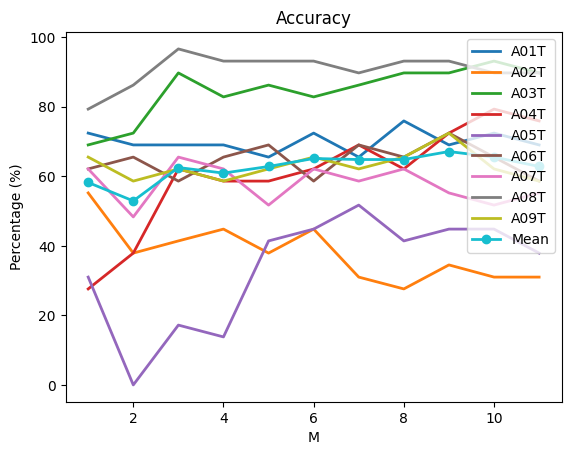

In [9]:
# plot
M_list = [i for i in range(1,M+1)]
# accuracy
fig, ax = plt.subplots()
for idx, subject in enumerate(participants):
    ax.plot(M_list, test_acc_all[subject].values(), linewidth=2.0)
ax.plot(M_list, test_acc_all['avg'].values(), 'o-', linewidth=2)
title = f"Accuracy"
ax.set_title(title)
ax.set_xlabel("M")
ax.set_ylabel("Percentage (%)")
ax.legend(participants+[f"Mean"], loc = 1)

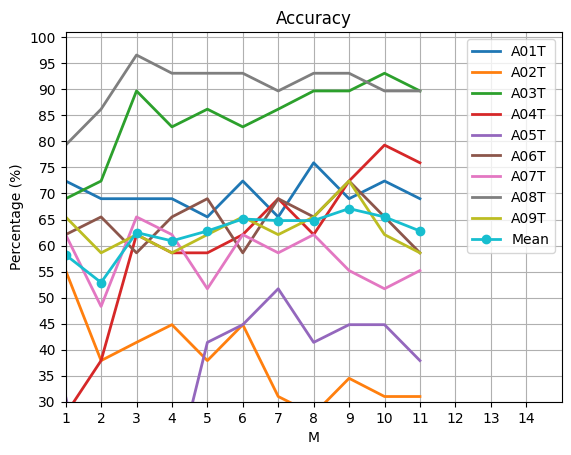

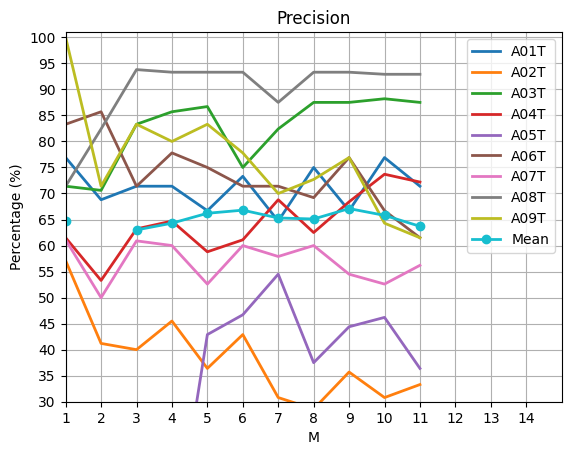

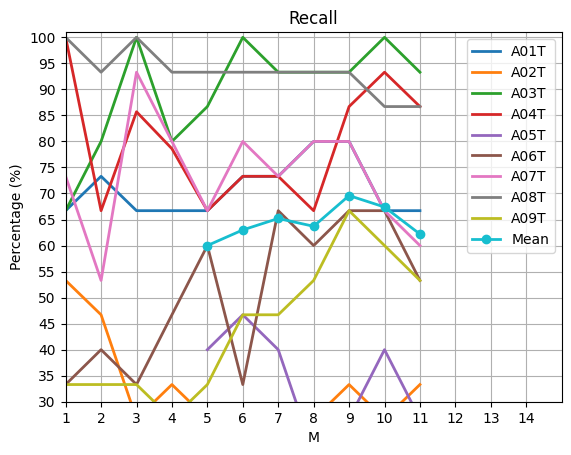

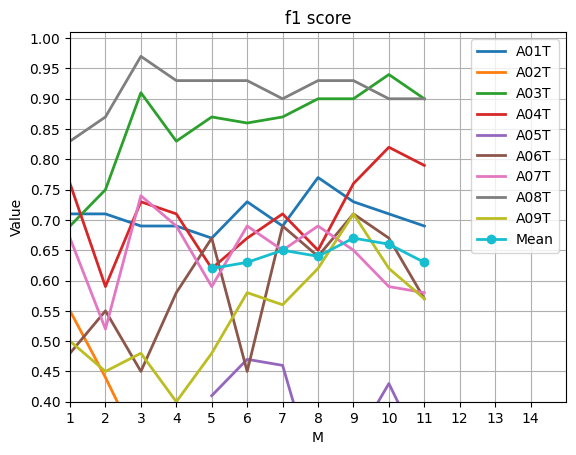

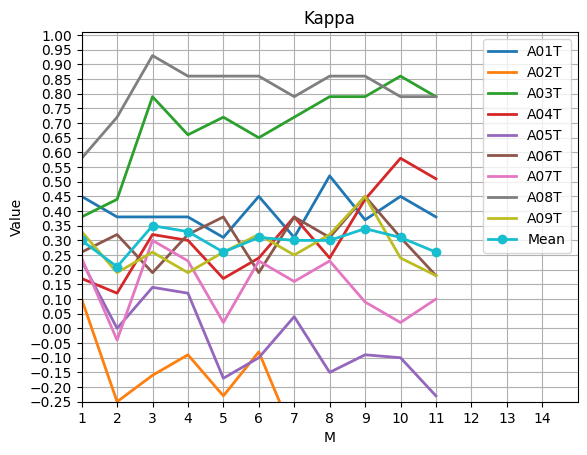

In [10]:
# plot
M_list = [i for i in range(1,M+1)]
# accuracy
fig, ax = plt.subplots()
for idx, subject in enumerate(participants):
    ax.plot(M_list, test_acc_all[subject].values(), linewidth=2.0)
ax.plot(M_list, test_acc_all['avg'].values(), 'o-', linewidth=2)
title = f"Accuracy"
ax.set_title(title)
ax.set_xlabel("M")
ax.set_ylabel("Percentage (%)")
ax.legend(participants+[f"Mean"], loc = 1)
ax.set(xlim=(1, 15), xticks=np.arange(1, 15),
    ylim=(30, 101), yticks=np.arange(30, 101, 5))
plt.grid()
name = title.split(' ')
name = '_'.join(name) + ".png"
name = saveResultPath + f'./{name}'
fig.savefig(name)
# precision
fig, ax = plt.subplots()
for idx, subject in enumerate(participants):
    ax.plot(M_list, test_precision_all[subject].values(), linewidth=2.0)
ax.plot(M_list, test_precision_all['avg'].values(), 'o-', linewidth=2)
title = f"Precision"
ax.set_title(title)
ax.set_xlabel("M")
ax.set_ylabel("Percentage (%)")
ax.legend(participants+[f"Mean"], loc = 1)
ax.set(xlim=(1, 15), xticks=np.arange(1, 15),
    ylim=(30, 101), yticks=np.arange(30, 101, 5))
plt.grid()
name = title.split(' ')
name = '_'.join(name) + ".png"
name = saveResultPath + f'./{name}'
fig.savefig(name)
# recall
fig, ax = plt.subplots()
for idx, subject in enumerate(participants):
    ax.plot(M_list, test_recall_all[subject].values(), linewidth=2.0)
ax.plot(M_list, test_recall_all['avg'].values(), 'o-', linewidth=2)
title = f"Recall"
ax.set_title(title)
ax.set_xlabel("M")
ax.set_ylabel("Percentage (%)")
ax.legend(participants+[f"Mean"], loc = 1)
ax.set(xlim=(1, 15), xticks=np.arange(1, 15),
    ylim=(30, 101), yticks=np.arange(30, 101, 5))
plt.grid()
name = title.split(' ')
name = '_'.join(name) + ".png"
name = saveResultPath + f'./{name}'
fig.savefig(name)
# f1 score
fig, ax = plt.subplots()
for idx, subject in enumerate(participants):
    ax.plot(M_list, test_f1_all[subject].values(), linewidth=2.0)
ax.plot(M_list, test_f1_all['avg'].values(), 'o-', linewidth=2)
title = "f1 score"
ax.set_title(title)
ax.set_xlabel("M")
ax.set_ylabel("Value")
ax.legend(participants+[f"Mean"], loc = 1)
ax.set(xlim=(1, 15), xticks=np.arange(1, 15),
    ylim=(0.40, 1.01), yticks=np.arange(0.40, 1.01,.05))
plt.grid()
name = title.split(' ')
name = '_'.join(name) + ".png"
name = saveResultPath + f'./{name}'
fig.savefig(name)
# kappa
fig, ax = plt.subplots()
for idx, subject in enumerate(participants):
    ax.plot(M_list, test_kappa_all[subject].values(), linewidth=2.0)
ax.plot(M_list, test_kappa_all['avg'].values(), 'o-', linewidth=2)
title = f"Kappa"
ax.set_title(title)
ax.set_xlabel("M")
ax.set_ylabel("Value")
ax.legend(participants+[f"Mean"], loc = 1)
ax.set(xlim=(1, 15), xticks=np.arange(1, 15),
    ylim=(-.25, 1.01), yticks=np.arange(-.25, 1.01,.05))
plt.grid()
name = title.split(' ')
name = '_'.join(name) + ".png"
name = saveResultPath + f'./{name}'
fig.savefig(name)

plt.show()

In [11]:
# data1 = {
#     'Accuracy' : [test_acc_all[subject] for subject in participants],
#     'Precicion': [test_precision_all[subject] for subject in participants],
#     'Recall'   : [test_recall_all[subject] for subject in participants]}
# df1 = pd.DataFrame(data1)
# fig = plt.figure(figsize=(5, 4))
# sns.boxplot(data=df1, palette="Set2")
# sns.stripplot(data=df1, color="black", size=5, jitter=True) # 疊加資料點
# plt.ylabel(f'Percentage (%)')
# plt.yticks(np.arange(50, 101, step=10))
# plt.grid(axis='y')
# plt.show()
# title = 'acc_pre_rec.png'
# name = title.split(' ')
# name = '_'.join(name) + ".png"
# name = saveResultPath + f'./{name}'
# fig.savefig(name)

# data2 = {
#     'F1-score' : [test_f1_all[subject] for subject in participants],
#     'Kappa'    : [test_kappa_all[subject] for subject in participants]}
# df2 = pd.DataFrame(data2)
# fig = plt.figure(figsize=(5, 4))
# sns.boxplot(data=df2, palette="Set2")
# sns.stripplot(data=df2, color="black", size=5, jitter=True) # 疊加資料點
# plt.ylabel(f'Score')
# plt.yticks(np.arange(0, 1.1, step=0.2))
# plt.grid(axis='y')
# plt.show()
# title = 'f1_kappa.png'
# name = title.split(' ')
# name = '_'.join(name) + ".png"
# name = saveResultPath + f'./{name}'
# fig.savefig(name)
